# Visualize & Describe Pattern Clusters (updated)

This notebook reads the dataset produced by `src/generate_celestial_dataset.py` (`events_celestial.csv`),
runs a comprehensive clustering that includes geographic coordinates (`latitude_num`, `longitude_num`) as features,
derives human-readable pattern names from the most discriminative attributes, and visualizes the results.

Key points:
- Latitude/longitude numeric columns are included by default in the clustering feature set and can be weighted.
- The notebook computes feature importance (mutual information + ANOVA) to find discriminators across clusters.
- Visualizations: interactive Folium map with pattern legend that shows pattern combinations, 2D projection (UMAP/PCA),
  histograms of discriminative features, and centroid heatmap/radar plots.

Before running: ensure required packages in your venv (see requirements.txt).

In [1]:
# Optional: install missing packages (uncomment to run inside notebook)
# !pip install pandas numpy seaborn matplotlib folium branca scikit-learn umap-learn
pass

In [2]:
import os
from IPython.display import display, IFrame
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.options.display.max_columns = 200
pd.options.display.width = 220


In [11]:
# Configuration
INPUT_CSV = '../events_celestial.csv'  # update path if needed
OUTPUT_PATT_CSV = 'events_celestial.comprehensive.patterned.csv'
PATTERN_ATTR_CSV = 'events_celestial.pattern_attributes.comprehensive.csv'
MAP_OUT = 'events_celestial_patterns_comprehensive_map.html'

METHOD = 'kmeans'   # 'kmeans' or 'dbscan'
N_CLUSTERS = 12
DBSCAN_EPS = 0.5
DBSCAN_MIN_SAMPLES = 6
SPATIAL_WEIGHT = 1.0  # multiply latitude_num/longitude_num prior to scaling
MAX_MAP_POINTS = 5000
TOP_FEATURES_NAME = 4
RANDOM_STATE = 0


In [12]:
if not os.path.isfile(INPUT_CSV):
    raise FileNotFoundError(f"Input file not found: {INPUT_CSV}")

df_raw = pd.read_csv(INPUT_CSV, low_memory=False)
print('Loaded rows:', len(df_raw))
display(df_raw.head())


Loaded rows: 23361


,time,_parsed_time_,_jd_,latitude,longitude,latitude_num,longitude_num,depth,mag,magType,depthError,magError,label,is_synthetic,source_event_index,Sun_ra_hours,Sun_dec_deg,Sun_distance_km,Sun_ang_diam_deg,Sun_helio_lon_deg,Sun_helio_lat_deg,Sun_pos_angle_deg,Sun_altitude_deg,Sun_is_above_horizon,Sun_is_combust,Moon_ra_hours,Moon_dec_deg,Moon_distance_km,Moon_ang_diam_deg,Moon_helio_lon_deg,Moon_helio_lat_deg,Moon_pos_angle_deg,Moon_altitude_deg,Moon_is_above_horizon,Moon_is_combust,Mercury_ra_hours,Mercury_dec_deg,Mercury_distance_km,Mercury_ang_diam_deg,Mercury_helio_lon_deg,Mercury_helio_lat_deg,Mercury_pos_angle_deg,Mercury_altitude_deg,Mercury_is_above_horizon,Mercury_is_combust,Venus_ra_hours,Venus_dec_deg,Venus_distance_km,Venus_ang_diam_deg,Venus_helio_lon_deg,Venus_helio_lat_deg,Venus_pos_angle_deg,Venus_altitude_deg,Venus_is_above_horizon,Venus_is_combust,Mars_ra_hours,Mars_dec_deg,Mars_distance_km,Mars_ang_diam_deg,Mars_helio_lon_deg,Mars_helio_lat_deg,Mars_pos_angle_deg,Mars_altitude_deg,Mars_is_above_horizon,Mars_is_combust,Jupiter_ra_hours,Jupiter_dec_deg,Jupiter_distance_km,Jupiter_ang_diam_deg,Jupiter_helio_lon_deg,Jupiter_helio_lat_deg,Jupiter_pos_angle_deg,Jupiter_altitude_deg,Jupiter_is_above_horizon,Jupiter_is_combust,Saturn_ra_hours,Saturn_dec_deg,Saturn_distance_km,Saturn_ang_diam_deg,Saturn_helio_lon_deg,Saturn_helio_lat_deg,Saturn_pos_angle_deg,Saturn_altitude_deg,Saturn_is_above_horizon,Saturn_is_combust,Sun_sid_long,Sun_sid_long_over_360,Sun_sid_lat,Sun_zodiac,Sun_zodiac_index,Sun_is_retrograde,Moon_sid_long,Moon_sid_long_over_360,Moon_sid_lat,Moon_zodiac,Moon_zodiac_index,Moon_is_retrograde,Mercury_sid_long,Mercury_sid_long_over_360,Mercury_sid_lat,Mercury_zodiac,Mercury_zodiac_index,Mercury_is_retrograde,Venus_sid_long,Venus_sid_long_over_360,Venus_sid_lat,Venus_zodiac,Venus_zodiac_index,Venus_is_retrograde,Mars_sid_long,Mars_sid_long_over_360,Mars_sid_lat,Mars_zodiac,Mars_zodiac_index,Mars_is_retrograde,Jupiter_sid_long,Jupiter_sid_long_over_360,Jupiter_sid_lat,Jupiter_zodiac,Jupiter_zodiac_index,Jupiter_is_retrograde,Saturn_sid_long,Saturn_sid_long_over_360,Saturn_sid_lat,Saturn_zodiac,Saturn_zodiac_index,Saturn_is_retrograde,Rahu_mean_sid_long,Rahu_mean_sid_long_over_360,Rahu_mean_sid_lat,Rahu_mean_zodiac,Rahu_mean_zodiac_index,Rahu_mean_is_retrograde,Rahu_mean_is_combust,Rahu_mean_is_above_horizon,Rahu_mean_altitude_deg,Ketu_mean_sid_long,Ketu_mean_sid_long_over_360,Ketu_mean_sid_lat,Ketu_mean_zodiac,Ketu_mean_zodiac_index,Ketu_mean_is_retrograde,Ketu_mean_is_combust,Ketu_mean_is_above_horizon,Ketu_mean_altitude_deg,Rahu_true_sid_long,Rahu_true_sid_long_over_360,Rahu_true_sid_lat,Rahu_true_zodiac,Rahu_true_zodiac_index,Rahu_true_is_retrograde,Rahu_true_is_combust,Rahu_true_is_above_horizon,Rahu_true_altitude_deg,Ketu_true_sid_long,Ketu_true_sid_long_over_360,Ketu_true_sid_lat,Ketu_true_zodiac,Ketu_true_zodiac_index,Ketu_true_is_retrograde,Ketu_true_is_combust,Ketu_true_is_above_horizon,Ketu_true_altitude_deg
0,1950-12-29T22:35:23.860000+00:00,1950-12-29 22:35:23.860000+00:00,2.433645e+06,23.854,91.844,23.854,91.844,15.0,5.90,mw,25.0,0.26,1,False,0,18.605181,-23.183151,1.471026e+08,0.542440,0.0,0.0,0.0,NaN,NaN,NaN,10.840160,8.511658,388085.341215,0.513006,0.853374,188.473050,267.573645,NaN,NaN,NaN,19.075350,-20.831802,1.035563e+08,0.002700,26.712034,175.091060,71.568420,NaN,NaN,NaN,19.415567,-23.117866,2.494591e+08,0.002780,2.542784,214.697086,92.063703,NaN,NaN,NaN,20.993888,-18.303881,3.120574e+08,0.001245,0.628335,245.437171,88.523624,NaN,NaN,NaN,22.482221,-10.678291,8.155059e+08,0.009824,0.338709,254.504411,87.682868,NaN,NaN,NaN,12.236509,0.916775,1.393652e+09,0.004788,-0.141938,266.941467,268.663178,NaN,NaN,NaN,277.655306,0.771265,-0.000052,Capricorn,10,NaN,160.031273,0.444531,1.039608,Virgo,6,NaN,284.373669,0.789927,1.774248,Capricorn,10,NaN,288.775977,0.802155,-1.095812,Capricorn,10,NaN,311.413794,0.865038,-1.180312,Aquarius,11,NaN,334.312280,0.928645,-1.071500,Pisces,12,NaN,182.207122,0.506

## Prepare features
- Ensure `latitude_num` and `longitude_num` exist and are numeric.
- Automatically select numeric columns and small-cardinality categorical columns.
- Apply spatial weight to latitude/longitude if requested.

In [13]:
# Ensure latitude_num/longitude_num exist
df = df_raw.copy().reset_index(drop=True)
if 'latitude_num' not in df.columns and 'latitude' in df.columns:
    df['latitude_num'] = pd.to_numeric(df['latitude'], errors='coerce')
if 'longitude_num' not in df.columns and 'longitude' in df.columns:
    df['longitude_num'] = pd.to_numeric(df['longitude'], errors='coerce')

# Meta columns to keep aside for display
meta_cols = ['time','latitude','longitude','latitude_num','longitude_num','label','is_synthetic','source_event_index']
meta_present = [c for c in meta_cols if c in df.columns]
print('Meta columns present:', meta_present)

# Build candidate feature lists
all_cols = [c for c in df.columns]
exclude = set(['_parsed_time_'])
candidates = [c for c in all_cols if c not in exclude and c not in meta_present]

numeric_feats = [c for c in candidates if pd.api.types.is_numeric_dtype(df[c])]
object_feats = [c for c in candidates if not pd.api.types.is_numeric_dtype(df[c])]

# treat small-cardinality object columns as categorical
categorical_feats = []
for c in object_feats:
    try:
        nunique = df[c].nunique(dropna=True)
    except Exception:
        nunique = 0
    if nunique <= 50:
        categorical_feats.append(c)

# ensure latitude_num/longitude_num included
for s in ['latitude_num','longitude_num']:
    if s in df.columns and s not in numeric_feats:
        numeric_feats.insert(0, s)

print('Numeric features count:', len(numeric_feats))
print('Categorical features count:', len(categorical_feats))
print('Sample numeric features:', numeric_feats[:30])
print('Sample categorical features:', categorical_feats[:20])


Meta columns present: ['time', 'latitude', 'longitude', 'latitude_num', 'longitude_num', 'label', 'is_synthetic', 'source_event_index']
Numeric features count: 144
Categorical features count: 12
Sample numeric features: ['longitude_num', 'latitude_num', '_jd_', 'depth', 'mag', 'depthError', 'magError', 'Sun_ra_hours', 'Sun_dec_deg', 'Sun_distance_km', 'Sun_ang_diam_deg', 'Sun_helio_lon_deg', 'Sun_helio_lat_deg', 'Sun_pos_angle_deg', 'Sun_altitude_deg', 'Sun_is_above_horizon', 'Sun_is_combust', 'Moon_ra_hours', 'Moon_dec_deg', 'Moon_distance_km', 'Moon_ang_diam_deg', 'Moon_helio_lon_deg', 'Moon_helio_lat_deg', 'Moon_pos_angle_deg', 'Moon_altitude_deg', 'Moon_is_above_horizon', 'Moon_is_combust', 'Mercury_ra_hours', 'Mercury_dec_deg', 'Mercury_distance_km']
Sample categorical features: ['magType', 'Sun_zodiac', 'Moon_zodiac', 'Mercury_zodiac', 'Venus_zodiac', 'Mars_zodiac', 'Jupiter_zodiac', 'Saturn_zodiac', 'Rahu_mean_zodiac', 'Ketu_mean_zodiac', 'Rahu_true_zodiac', 'Ketu_true_zodiac']


## Build feature matrix
- Numeric features: median impute, apply spatial weight to latitude/longitude.
- Categorical features: ordinal-encode (fallback to codes if encoding fails).
- Concatenate numeric + encoded categorical arrays and standard scale.

In [14]:
# numeric handling
num_df = df[numeric_feats].copy() if numeric_feats else pd.DataFrame(index=df.index)
for c in num_df.columns:
    num_df[c] = pd.to_numeric(num_df[c], errors='coerce')
    med = num_df[c].median(skipna=True)
    if pd.isna(med):
        med = 0.0
    num_df[c] = num_df[c].fillna(med)

# apply spatial weight
if SPATIAL_WEIGHT != 1.0:
    for s in ['latitude_num','longitude_num']:
        if s in num_df.columns:
            num_df[s] = num_df[s].astype(float) * float(SPATIAL_WEIGHT)

# categorical encoding
cat_df_enc = pd.DataFrame(index=df.index)
if categorical_feats:
    cat_df = df[categorical_feats].astype(str).fillna('~NA~')
    enc = OrdinalEncoder(dtype=float)
    try:
        cat_enc = enc.fit_transform(cat_df)
        cat_df_enc = pd.DataFrame(cat_enc, columns=categorical_feats, index=df.index)
    except Exception:
        # fallback
        cat_df_enc = pd.DataFrame({c: pd.Categorical(cat_df[c]).codes for c in categorical_feats}, index=df.index)

X_numeric = num_df.values if not num_df.empty else np.empty((len(df), 0))
X_cat = cat_df_enc.values if not cat_df_enc.empty else np.empty((len(df), 0))
X = np.hstack([X_numeric, X_cat]) if (X_numeric.size or X_cat.size) else np.empty((len(df),0))
feature_names = list(num_df.columns) + list(cat_df_enc.columns)
print('Feature matrix shape:', X.shape)


Feature matrix shape: (23361, 156)


## Clustering
Scale features and run the configured clustering algorithm (KMeans or DBSCAN).

In [15]:
if X.size == 0:
    raise RuntimeError('No features available to cluster on.')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

if METHOD == 'kmeans':
    model = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    meta = {'model': 'kmeans', 'n_clusters': N_CLUSTERS}
elif METHOD == 'dbscan':
    model = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
    labels = model.fit_predict(X_scaled)
    meta = {'model': 'dbscan', 'eps': DBSCAN_EPS, 'min_samples': DBSCAN_MIN_SAMPLES}
else:
    raise RuntimeError('Unknown METHOD')

df['cluster_id'] = labels.astype(int)
df['pattern_label'] = df['cluster_id'].apply(lambda p: 'noise' if p == -1 else f'pattern_{int(p)}')
print('Cluster distribution:')
display(df['pattern_label'].value_counts().head(40))


Cluster distribution:


pattern_label
pattern_3     3351
pattern_4     2809
pattern_8     2551
pattern_11    2159
pattern_9     2014
pattern_1     1874
pattern_10    1691
pattern_2     1661
pattern_7     1569
pattern_5     1361
pattern_0     1218
pattern_6     1103
Name: count, dtype: int64

## Feature importance
- Compute mutual information on the scaled matrix and ANOVA F for numeric features (if applicable).
- Use these to choose discriminative attributes for naming clusters.

In [16]:
labels_for_scores = df['cluster_id'].values
feature_scores = pd.Series(0.0, index=feature_names)

try:
    if len(np.unique(labels_for_scores)) > 1:
        mi = mutual_info_classif(np.nan_to_num(X_scaled), labels_for_scores, random_state=RANDOM_STATE)
        mi_series = pd.Series(mi, index=feature_names).sort_values(ascending=False)
        for i, f in enumerate(mi_series.index):
            feature_scores[f] += (len(mi_series) - i)
except Exception as e:
    print('MI computation failed:', e)

numeric_scores = pd.Series(dtype=float)
if len(numeric_feats) > 0 and len(np.unique(labels_for_scores)) > 1:
    try:
        fvals, pvals = f_classif(num_df.values, labels_for_scores)
        numeric_scores = pd.Series(fvals, index=num_df.columns).sort_values(ascending=False)
        
        for i, f in enumerate(numeric_scores.index):
            if f in feature_scores.index:
                feature_scores[f] += (len(numeric_scores) - i) * 1.5
    except Exception as e:
        print('ANOVA failed:', e)

print('Top features by combined score:')
display(feature_scores.sort_values(ascending=False).head(30))


Top features by combined score:


Rahu_true_sid_long             364.0
Rahu_true_sid_long_over_360    363.5
Rahu_mean_sid_long             360.5
Ketu_true_sid_long             358.5
Rahu_mean_sid_long_over_360    358.0
Ketu_true_sid_long_over_360    356.0
Rahu_mean_zodiac_index         350.0
Ketu_mean_sid_long_over_360    349.0
Saturn_sid_long_over_360       347.0
Saturn_sid_long                346.5
Ketu_mean_sid_long             346.5
Rahu_true_zodiac_index         342.5
Ketu_true_zodiac_index         340.0
Saturn_ra_hours                340.0
Ketu_mean_zodiac_index         339.5
Saturn_dec_deg                 324.5
Saturn_zodiac_index            321.0
Sun_ang_diam_deg               314.5
Sun_distance_km                314.0
Sun_dec_deg                    313.5
Jupiter_sid_long               311.0
Jupiter_sid_long_over_360      310.5
_jd_                           310.5
Jupiter_ra_hours               307.0
Sun_sid_long                   305.0
Sun_sid_long_over_360          304.5
Mercury_ra_hours               301.5
M

## Derive human-readable pattern names
- For each cluster, select top numeric discriminators (z-score vs global median) and top categorical modes
  to assemble a short descriptive `pattern_name`.

In [17]:
# cluster sizes
sizes = df['cluster_id'].value_counts().to_dict()

# numeric medians and z-scores
if len(numeric_feats) > 0:
    medians = df.groupby('cluster_id')[numeric_feats].median()
    global_med = df[numeric_feats].median()
    global_std = df[numeric_feats].std().replace(0, np.nan).fillna(1.0)
    z = (medians - global_med) / global_std
    abs_z = z.abs()
else:
    medians = pd.DataFrame()
    abs_z = pd.DataFrame()

# categorical modes
cat_modes = {}
for c in categorical_feats:
    try:
        cat_modes[c] = df.groupby('cluster_id')[c].agg(lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else np.nan)
    except Exception:
        cat_modes[c] = pd.Series(dtype=object)

pattern_rows = []
for cid in sorted(df['cluster_id'].unique()):
    size = int(sizes.get(cid, 0))
    if cid == -1:
        pname = 'noise'
    else:
        parts = []
        # top numeric discriminators by abs z
        if not abs_z.empty and cid in abs_z.index:
            top_num = abs_z.loc[cid].sort_values(ascending=False).index[:TOP_FEATURES_NAME].tolist()
            for f in top_num:
                try:
                    val = medians.at[cid, f]
                    parts.append(f"{f}={val:.2f}")
                except Exception:
                    pass
        # top categorical modes (up to 2)
        cat_parts = []
        for c in list(cat_modes.keys())[:2]:
            try:
                mv = cat_modes[c].at[cid]
                if pd.notna(mv):
                    cat_parts.append(f"{c.split('_')[0]}={mv}")
            except Exception:
                pass
        # fallback to top combined feature scores
        if not parts:
            for f in feature_scores.sort_values(ascending=False).index[:TOP_FEATURES_NAME]:
                if f in numeric_feats:
                    try:
                        val = medians.at[cid, f]
                        parts.append(f"{f}={val:.2f}")
                    except Exception:
                        pass
        name_parts = parts + cat_parts
        if not name_parts:
            pname = f'pattern_{int(cid)}'
        else:
            pname = f'pattern_{int(cid)} | ' + '; '.join(name_parts[:6])
    pattern_rows.append({'cluster_id': int(cid), 'pattern_size': size, 'pattern_name': pname})

pattern_attributes = pd.DataFrame(pattern_rows).set_index('cluster_id').sort_values('pattern_size', ascending=False)
pattern_attributes['top_features'] = ','.join(feature_scores.sort_values(ascending=False).index[:min(20,len(feature_scores))])
pattern_attributes = pattern_attributes.reset_index()
display(pattern_attributes.head(50))


,cluster_id,pattern_size,pattern_name,top_features
0,3,3351,pattern_3 | Mars_pos_angle_deg=245.60; Saturn_...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
1,4,2809,pattern_4 | _jd_=2407377.92; Rahu_true_zodiac_...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
2,8,2551,pattern_8 | Jupiter_dec_deg=19.84; Saturn_dec_...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
3,11,2159,pattern_11 | Ketu_mean_zodiac_index=2.00; Ketu...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
4,9,2014,pattern_9 | Saturn_dec_deg=19.12; Saturn_ra_ho...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
5,1,1874,pattern_1 | Saturn_zodiac_index=11.00; Rahu_tr...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
6,10,1691,pattern_10 | Saturn_pos_angle_deg=91.82; Jupit...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
7,2,1661,pattern_2 | Saturn_ang_diam_deg=0.01; Saturn_d...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
8,7,1569,pattern_7 | Saturn_zodiac_index=11.00; Saturn_...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."
9,5,1361,pattern_5 | Ketu_mean_zodiac_index=2.00; Ketu_...,"Rahu_true_sid_long,Rahu_true_sid_long_over_360..."


In [18]:
# attach pattern_name back to rows
id_to_name = pattern_attributes.set_index('cluster_id')['pattern_name'].to_dict()
df['pattern_name'] = df['cluster_id'].map(lambda p: id_to_name.get(int(p), ('noise' if int(p)==-1 else f'pattern_{int(p)}')))
df['pattern_label'] = df['pattern_name']

# Save outputs
df.to_csv(OUTPUT_PATT_CSV, index=False)
pattern_attributes.to_csv(PATTERN_ATTR_CSV, index=False)
print('Saved patterned CSV to', OUTPUT_PATT_CSV)
print('Saved pattern attributes to', PATTERN_ATTR_CSV)


Saved patterned CSV to events_celestial.comprehensive.patterned.csv
Saved pattern attributes to events_celestial.pattern_attributes.comprehensive.csv


## Visualizations
- Interactive Folium map with a legend that displays the pattern name and the short pattern combination (top features)
- 2D projection (UMAP if available, otherwise PCA) colored by pattern_name
- Distributions of top discriminative numeric features across top patterns
- Centroid heatmap for numeric features for top patterns

In [20]:
# Folium map
map_df = df.dropna(subset=['latitude_num','longitude_num']).copy()
if map_df.empty:
    print('No coordinates available; skipping map generation')
else:
    center_lat = float(map_df['latitude_num'].median())
    center_lon = float(map_df['longitude_num'].median())
    m = folium.Map(location=[center_lat, center_lon], zoom_start=3, tiles='CartoDB positron')
    marker_cluster = MarkerCluster(name='events').add_to(m)

    # color map keyed on pattern_name
    patt_names = pattern_attributes['pattern_name'].tolist()
    palette = sns.color_palette('tab20', n_colors=max(8, len(patt_names)))
    from matplotlib.colors import rgb2hex
    color_map = {patt_names[i]: rgb2hex(palette[i % len(palette)]) for i in range(len(patt_names))}

    sample_df = map_df if len(map_df) <= MAX_MAP_POINTS else map_df.sample(n=MAX_MAP_POINTS, random_state=RANDOM_STATE)
    for _, row in sample_df.iterrows():
        lat = float(row['latitude_num'])
        lon = float(row['longitude_num'])
        pname = str(row.get('pattern_name', 'unknown'))
        color = color_map.get(pname, '#3186cc')
        popup_html = f"<b>pattern:</b> {pname}<br/><b>time:</b> {row.get('time')}<br/>"
        if 'mag' in row.index and not pd.isna(row.get('mag')):
            popup_html += f"<b>mag:</b> {row.get('mag')}<br/>"
        folium.CircleMarker(location=[lat, lon], radius=4, color=color, fill=True, fill_opacity=0.7, popup=folium.Popup(popup_html, max_width=300)).add_to(marker_cluster)

    # legend
    legend_html = '<div style="position: fixed; bottom: 50px; left: 10px; width: 420px; height: 320px; overflow: auto; background: white; padding: 8px; border: 1px solid #ccc; z-index:9999;">'
    legend_html += '<b>Pattern legend (name : size : top features)</b><br/>'
    for i, row in pattern_attributes.head(50).iterrows():
        name = row['pattern_name']
        size = int(row['pattern_size'])
        topf = (row.get('top_features') or '')[:160]
        color = color_map.get(name, '#333333')
        legend_html += f'<div style="display:flex; align-items:center; gap:8px; margin-bottom:4px;"><div style="width:12px; height:12px; background:{color}; margin-right:6px;"></div><div style="font-size:11px">{name} ({size})<br/><span style="color:#666; font-size:10px">{topf}</span></div></div>'
    legend_html += '</div>'
    m.get_root().html.add_child(folium.Element(legend_html))
    m.save(MAP_OUT)
    print('Map saved to', MAP_OUT)
    display(IFrame(MAP_OUT, width='100%', height=600))


Map saved to events_celestial_patterns_comprehensive_map.html


In [ ]:
# 2D projection using UMAP if available, otherwise PCA
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    X_proj = reducer.fit_transform(X_scaled)
    proj_name = 'UMAP'
except Exception:
    print('UMAP not available; using PCA')
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_proj = pca.fit_transform(X_scaled)
    proj_name = 'PCA'

proj_df = pd.DataFrame(X_proj, columns=['proj1','proj2'])
proj_df['pattern'] = df['pattern_name'].astype(str).values

plt.figure(figsize=(10,6))
unique_patterns = proj_df['pattern'].unique()
palette2 = sns.color_palette('tab20', n_colors=min(20, len(unique_patterns)))
col_map2 = {p: palette2[i % len(palette2)] for i,p in enumerate(unique_patterns)}
for p in unique_patterns:
    sub = proj_df[proj_df['pattern']==p]
    plt.scatter(sub['proj1'], sub['proj2'], label=p, s=10, color=col_map2[p], alpha=0.7)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize='small')
plt.title(f'{proj_name} projection colored by pattern')
plt.xlabel('proj1'); plt.ylabel('proj2')
plt.tight_layout()
plt.show()


Top numeric features to visualize: ['Rahu_true_sid_long', 'Rahu_true_sid_long_over_360', 'Rahu_mean_sid_long', 'Ketu_true_sid_long', 'Rahu_mean_sid_long_over_360', 'Ketu_true_sid_long_over_360', 'Rahu_mean_zodiac_index', 'Ketu_mean_sid_long_over_360', 'Saturn_sid_long_over_360', 'Saturn_sid_long']


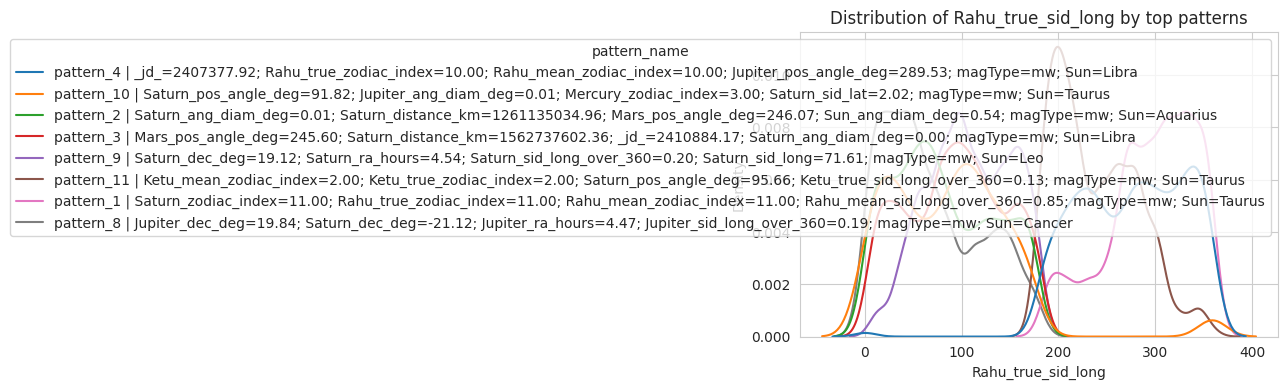

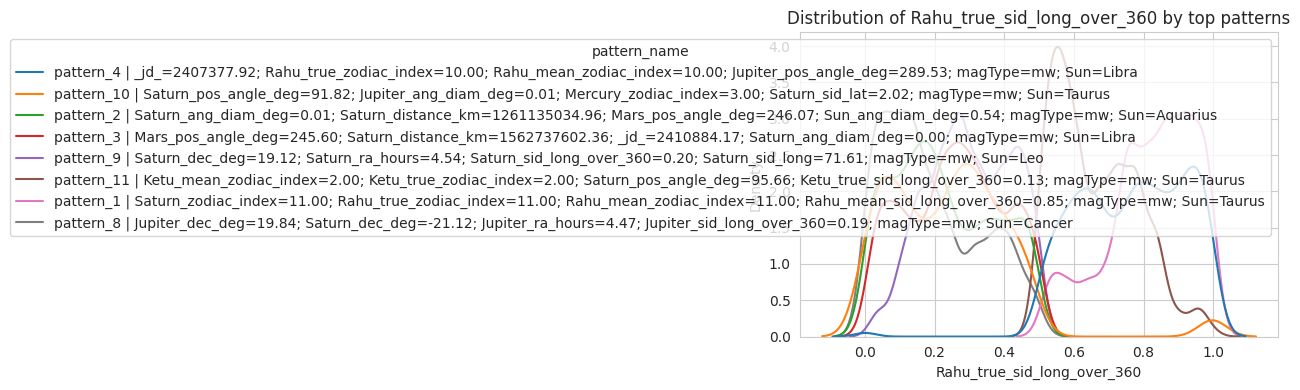

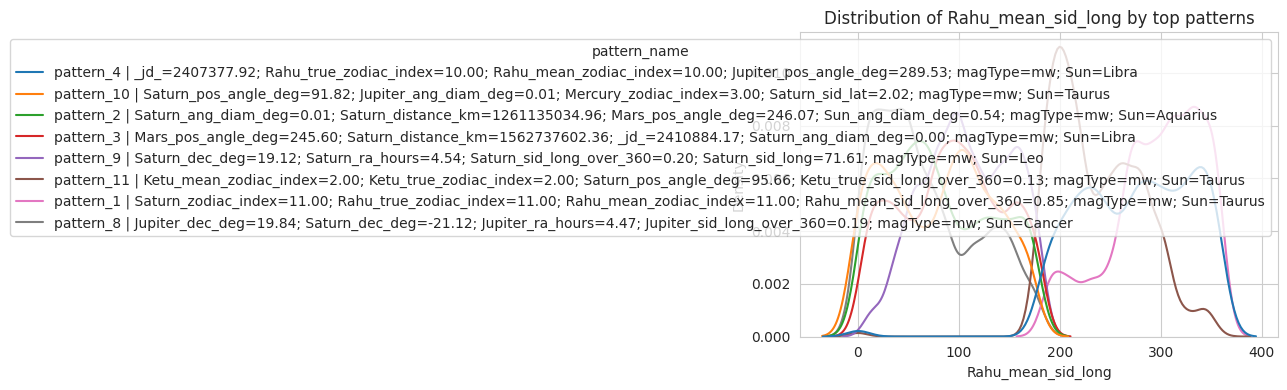

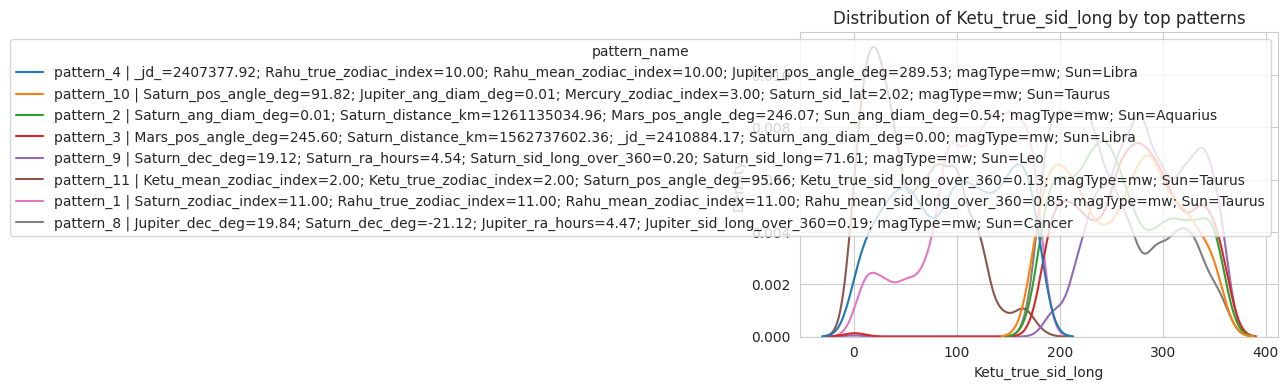

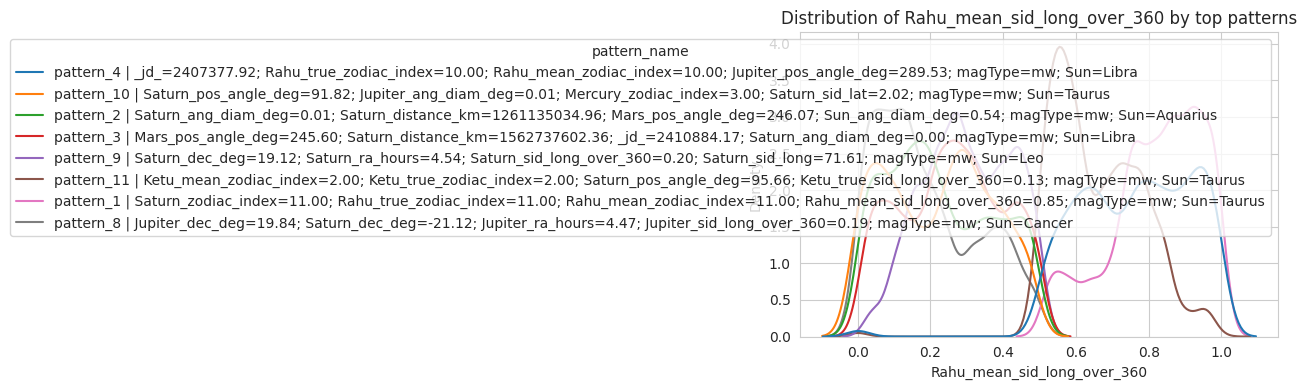

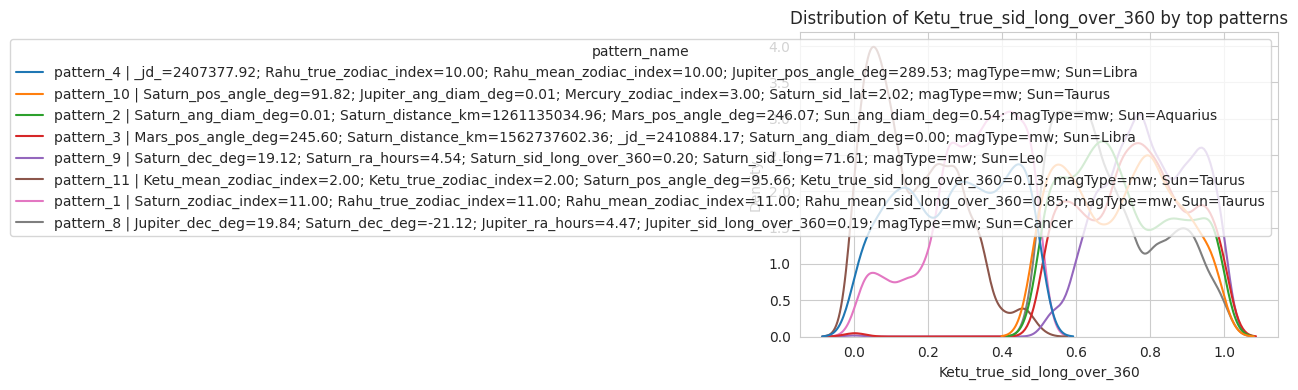

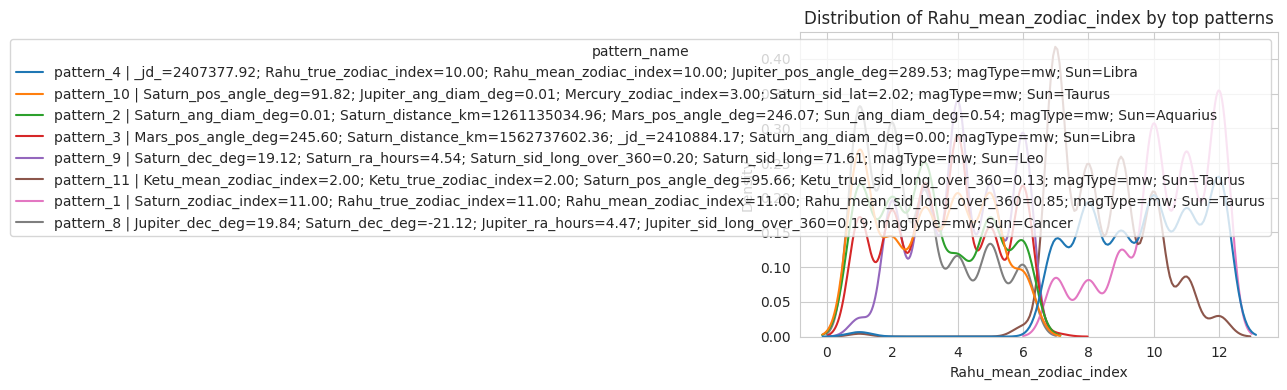

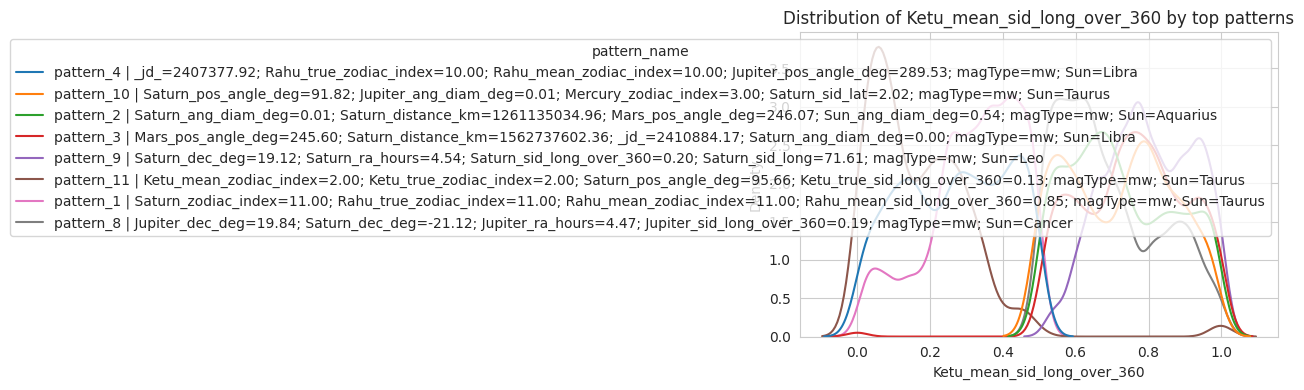

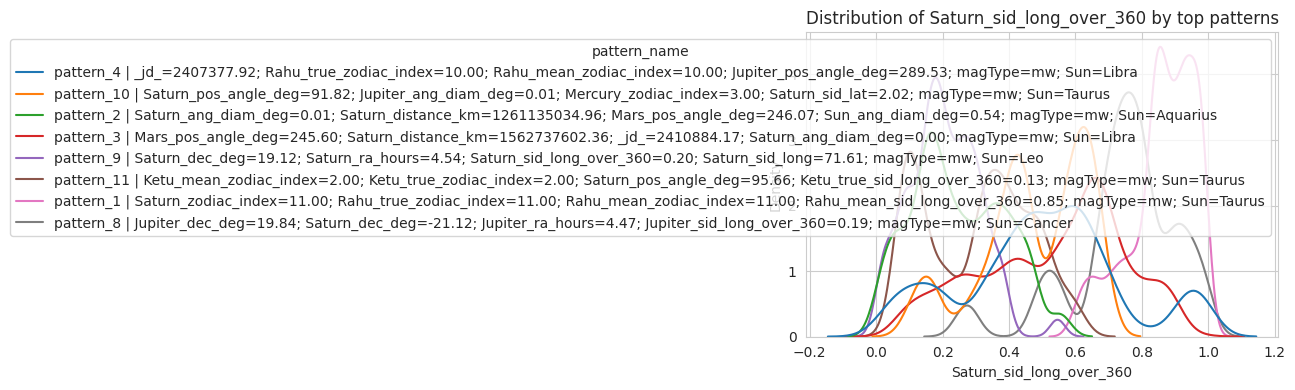

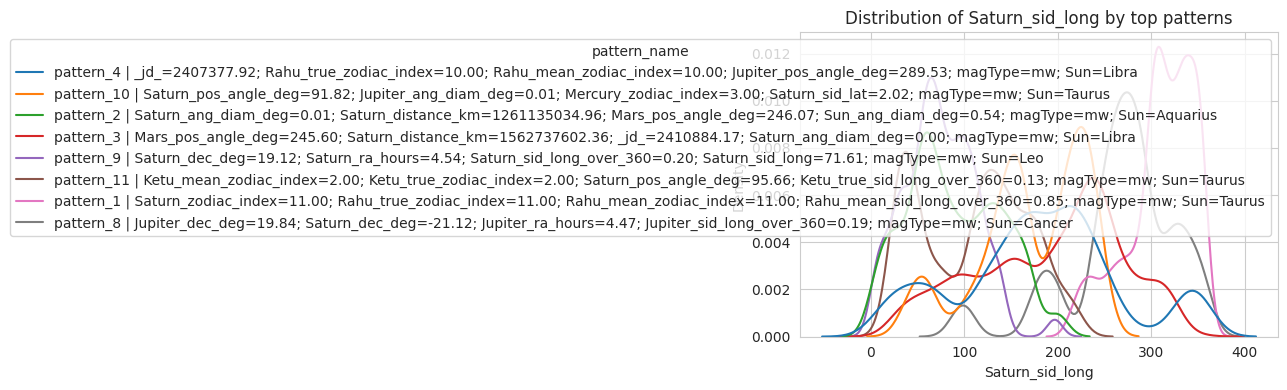

In [21]:
# Visualize top discriminative numeric features
top_numeric = [f for f in feature_scores.sort_values(ascending=False).index if f in numeric_feats][:10]
print('Top numeric features to visualize:', top_numeric)

TOPK_PATTERNS = pattern_attributes['pattern_name'].head(8).tolist()
df_vis = df[df['pattern_name'].isin(TOPK_PATTERNS)] if TOPK_PATTERNS else df

for feat in top_numeric:
    plt.figure(figsize=(10,4))
    try:
        sns.kdeplot(data=df_vis, x=feat, hue='pattern_name', common_norm=False, fill=False)
        plt.title(f'Distribution of {feat} by top patterns')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Failed to plot', feat, e)


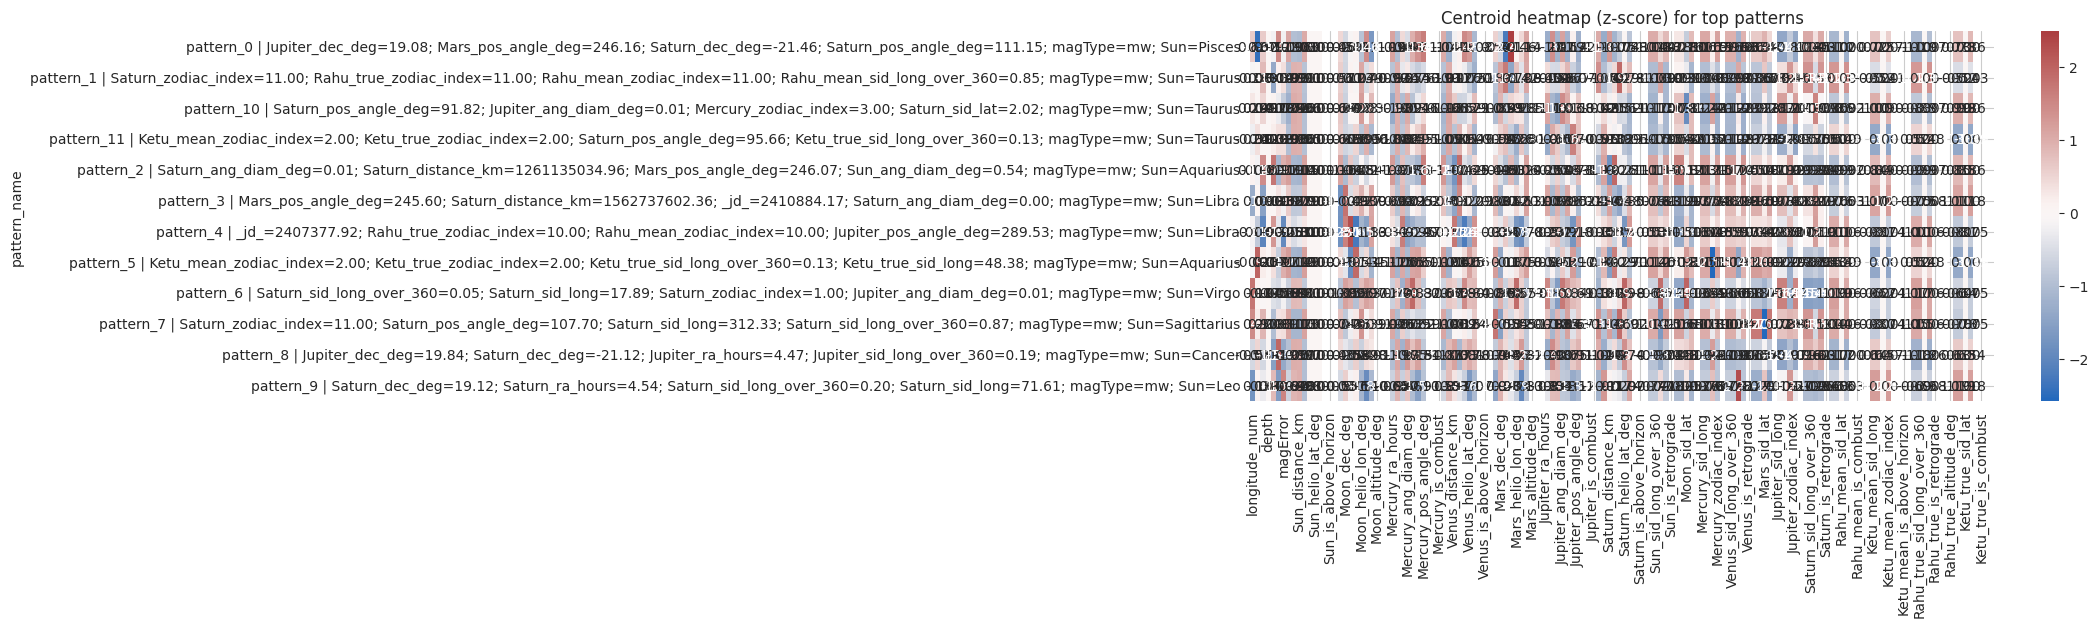

In [22]:
# Centroid heatmap for numeric features for top patterns
top_patterns = pattern_attributes['pattern_name'].head(12).tolist()
if top_patterns and numeric_feats:
    centroids = df[df['pattern_name'].isin(top_patterns)].groupby('pattern_name')[numeric_feats].median()
    # z-score normalize centroids for heatmap
    centroids_z = (centroids - centroids.mean()) / centroids.std().replace(0,1)
    plt.figure(figsize=(12, max(4, len(centroids_z)*0.4)))
    sns.heatmap(centroids_z, annot=True, fmt='.2f', cmap='vlag', center=0)
    plt.title('Centroid heatmap (z-score) for top patterns')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric centroids to show.')


## Save outputs for downstream use
- `OUTPUT_PATT_CSV` contains per-row pattern labels and pattern_name
- `PATTERN_ATTR_CSV` contains one row per pattern summarizing pattern_size and top features
- A map HTML file is created for interactive exploration

In [23]:
print('Writing outputs (already saved earlier):')
print('Pattern CSV:', OUTPUT_PATT_CSV)
print('Pattern attributes CSV:', PATTERN_ATTR_CSV)
print('Map HTML:', MAP_OUT)

# small legend JSON for quick UI consumption
legend = pattern_attributes[['cluster_id','pattern_name','pattern_size','top_features']].to_dict(orient='records')
import json
with open('events_celestial_pattern_legend.json','w') as fh:
    json.dump(legend, fh, indent=2)
print('Saved legend JSON: events_celestial_pattern_legend.json')


Writing outputs (already saved earlier):
Pattern CSV: events_celestial.comprehensive.patterned.csv
Pattern attributes CSV: events_celestial.pattern_attributes.comprehensive.csv
Map HTML: events_celestial_patterns_comprehensive_map.html
Saved legend JSON: events_celestial_pattern_legend.json


In [1]:
# === New final cell: generate an expanded CSV of available patterns and spread their attributes into columns ===
try:
    patt = pattern_attributes.copy()
except NameError:
    # load from file if pattern_attributes not in memory
    if os.path.isfile(PATTERN_ATTR_CSV):
        patt = pd.read_csv(PATTERN_ATTR_CSV)
    else:
        raise RuntimeError('pattern_attributes not found in notebook and PATTERN_ATTR_CSV missing')

# Ensure pattern_attributes has expected columns
print('Pattern attributes rows:', len(patt))
display(patt.head())

# Split top_features into separate columns (top_feature_1..N)
MAX_TOP_FEATS = 10
def split_top_features(s):
    if pd.isna(s) or str(s).strip() == '':
        return [None] * MAX_TOP_FEATS
    parts = [p.strip() for p in str(s).split(',') if p.strip()]
    parts = parts[:MAX_TOP_FEATS]
    parts += [None] * (MAX_TOP_FEATS - len(parts))
    return parts

top_feat_cols = [f'top_feature_{i+1}' for i in range(MAX_TOP_FEATS)]
top_feats_expanded = patt['top_features'].fillna('').apply(split_top_features).tolist()
top_feats_df = pd.DataFrame(top_feats_expanded, columns=top_feat_cols, index=patt.index)

# Parse pattern_name into a short label + descriptor (split on ' | ')
def parse_pattern_name(name):
    if pd.isna(name):
        return (None, None)
    s = str(name)
    if '|' in s:
        left, right = s.split('|', 1)
        return (left.strip(), right.strip())
    return (s.strip(), '')

parsed = patt['pattern_name'].fillna('').apply(parse_pattern_name)
patt[['pattern_short','pattern_descriptor']] = pd.DataFrame(parsed.tolist(), index=patt.index)

# Flatten any median_/mode_ columns already present in patt (they will be preserved)
# Ensure column names are CSV-friendly
patt_cols = patt.copy()
patt_cols.columns = [c.replace(' ', '_').replace('/', '_') for c in patt_cols.columns]

# Combine everything into expanded dataframe
expanded = pd.concat([patt_cols.reset_index(drop=True), top_feats_df.reset_index(drop=True)], axis=1)

# Optionally, also include representative sample row for each pattern from the main df
REP_COLS = ['time','latitude','longitude','mag','label','is_synthetic']
rep_present = [c for c in REP_COLS if c in df.columns]
reps = []
for cid in expanded['cluster_id'].tolist():
    try:
        # choose median time row for the cluster as representative
        rows = df[df['cluster_id'] == int(cid)]
        if not rows.empty:
            rep = rows.iloc[0][rep_present].to_dict()
        else:
            rep = {c: None for c in rep_present}
    except Exception:
        rep = {c: None for c in rep_present}
    reps.append(rep)
if reps:
    reps_df = pd.DataFrame(reps)
    
    expanded = pd.concat([expanded.reset_index(drop=True), reps_df.reset_index(drop=True)], axis=1)

# Final cleanup: ensure deterministic column order: id, short name, size, descriptor, top_features, top_feature_1..N, medians/modes
cols_order = ['cluster_id','pattern_short','pattern_name','pattern_descriptor','pattern_size','top_features'] + top_feat_cols
other_cols = [c for c in expanded.columns if c not in cols_order]
final_cols = cols_order + other_cols
expanded = expanded[final_cols]

OUT_EXPANDED = 'events_celestial_pattern_expanded.csv'
expanded.to_csv(OUT_EXPANDED, index=False)
print('Wrote expanded pattern CSV to', OUT_EXPANDED)
display(expanded.head(20))


NameError: name 'os' is not defined

### Next steps / tuning advice
- Increase N_CLUSTERS for finer patterns or use DBSCAN for density-based clustering.
- Adjust SPATIAL_WEIGHT to give more/less influence to geographic location.
- Consider engineering circular features for angles (sine/cosine of longitudes / RA) to avoid wrap-around issues.
- If you want textual summaries for patterns (sentences), I can add an automatic summary generator.
